<h3> Installing Important Libraries </h3>

In [1]:
!pip install brainflow
!pip install keyboard


[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


<h3> The Pipeline </h3>

In [3]:
from brainflow.board_shim import BrainFlowInputParams, BoardShim
from brainflow.data_filter import DataFilter, FilterTypes
import keyboard
import time

params = BrainFlowInputParams()
params.serial_port = 'COM3'
board_id = 0  # OpenBCI Cyton

board = BoardShim(board_id, params)

board.prepare_session()
board.start_stream()
print("Streaming started")

# State tracking
EYES_OPEN = 1
EYES_CLOSED = 2

current_state = EYES_OPEN
board.insert_marker(current_state)
print("Initial state: EYES OPEN")

try:
    while True:
        if keyboard.is_pressed('h'):
            # toggle state
            if current_state == EYES_OPEN:
                current_state = EYES_CLOSED
                print("EYES CLOSED")
            else:
                current_state = EYES_OPEN
                print("EYES OPEN")

            board.insert_marker(current_state)
            time.sleep(0.4)

        if keyboard.is_pressed('q'):
            print("Quit key pressed")
            break

        time.sleep(0.01)

except KeyboardInterrupt:
    print("Stopping...")

finally:
    data = board.get_board_data()
    board.stop_stream()
    board.release_session()
    print("Session ended")

Streaming started
Initial state: EYES OPEN
EYES CLOSED
EYES OPEN
EYES CLOSED
EYES OPEN
EYES CLOSED
EYES OPEN
EYES CLOSED
EYES OPEN
EYES CLOSED
EYES OPEN
EYES CLOSED
EYES OPEN
EYES CLOSED
EYES OPEN
EYES CLOSED
EYES OPEN
EYES CLOSED
EYES OPEN
EYES CLOSED
EYES OPEN
EYES CLOSED
EYES OPEN
EYES CLOSED
EYES OPEN
EYES CLOSED
EYES OPEN
EYES CLOSED
EYES OPEN
EYES CLOSED
EYES OPEN
EYES CLOSED
EYES OPEN
EYES CLOSED
EYES OPEN
EYES CLOSED
EYES OPEN
EYES CLOSED
EYES OPEN
EYES CLOSED
EYES OPEN
EYES CLOSED
EYES OPEN
EYES CLOSED
EYES OPEN
EYES CLOSED
EYES OPEN
EYES CLOSED
EYES OPEN
EYES CLOSED
EYES OPEN
EYES CLOSED
EYES OPEN
EYES CLOSED
EYES OPEN
EYES CLOSED
EYES OPEN
EYES CLOSED
EYES OPEN
EYES CLOSED
EYES OPEN
EYES CLOSED
EYES OPEN
EYES CLOSED
EYES OPEN
EYES CLOSED
EYES OPEN
EYES CLOSED
EYES OPEN
EYES CLOSED
EYES OPEN
EYES CLOSED
EYES OPEN
EYES CLOSED
EYES OPEN
EYES CLOSED
EYES OPEN
EYES CLOSED
EYES OPEN
EYES CLOSED
EYES OPEN
EYES CLOSED
EYES OPEN
EYES CLOSED
EYES OPEN
EYES CLOSED
EYES OPEN
EYES CLOSED

In [4]:
copy_data = data.copy()

In [11]:
data = copy_data

<h3> Get EEG data and marker channels </h3>

In [ ]:
import numpy as np

eeg_data = data[BoardShim.get_eeg_channels(board_id), :]
print(f"Collected EEG data shape: {eeg_data.shape}")

fs = 250

for ch in range(eeg_data.shape[0]):
    # Band-pass: remove DC + high-frequency noise
    DataFilter.perform_bandpass(
        eeg_data[ch],
        fs,
        0.5,
        40.0,
        4,
        FilterTypes.BUTTERWORTH.value,
        0
    )

    # Notch: remove 50 Hz mains noise (Germany)
    DataFilter.perform_bandstop(
        eeg_data[ch],
        fs,
        48.0,
        52.0,
        4,
        FilterTypes.BUTTERWORTH.value,
        0
    )

cut = 1250  # samples = 5 seconds

eeg_data = eeg_data[:, cut:]

marker_data = data[BoardShim.get_marker_channel(board_id), :]

orig_marker_indices = np.where(marker_data != 0)[0]
orig_marker_vals = marker_data[orig_marker_indices]
marker_indices = orig_marker_indices - cut
valid = marker_indices >= 0

marker_indices = marker_indices[valid]
marker_vals = orig_marker_vals[valid]
states = []

for i in range(len(marker_indices)):
    start = marker_indices[i]
    end = marker_indices[i + 1] if i + 1 < len(marker_indices) else eeg_data.shape[1]
    label = int(marker_vals[i])

    states.append((start, end, label))

window_size = fs        # 1 second
step_size = fs // 4     # 250 ms overlap

X = []
y = []

for start, end, label in states:
    # optional: skip first 0.5 s after transition
    start += int(0.5 * fs)

    for i in range(start, end - window_size, step_size):
        window = eeg_data[:, i:i + window_size]
        X.append(window)
        y.append(label)

X = np.array(X)
y = np.array(y)

print("Total samples:", X.shape[0])
print("Shape of feature matrix X and label vector y:")
print(X.shape, y.shape)

# save to disk
np.savez(
    'raw_eye_data.npz',
    X=X,
    y=y,
    fs=fs,
    window_size=window_size,
    step_size=step_size
)

unique, counts = np.unique(y, return_counts=True)
print("Label distribution:", dict(zip(unique, counts)))

Collected EEG data shape: (8, 149383)
Total samples: 1666
Shape of feature matrix X and label vector y:
(1666, 8, 250) (1666,)


<h3> Plotting Output for every channel </h3>

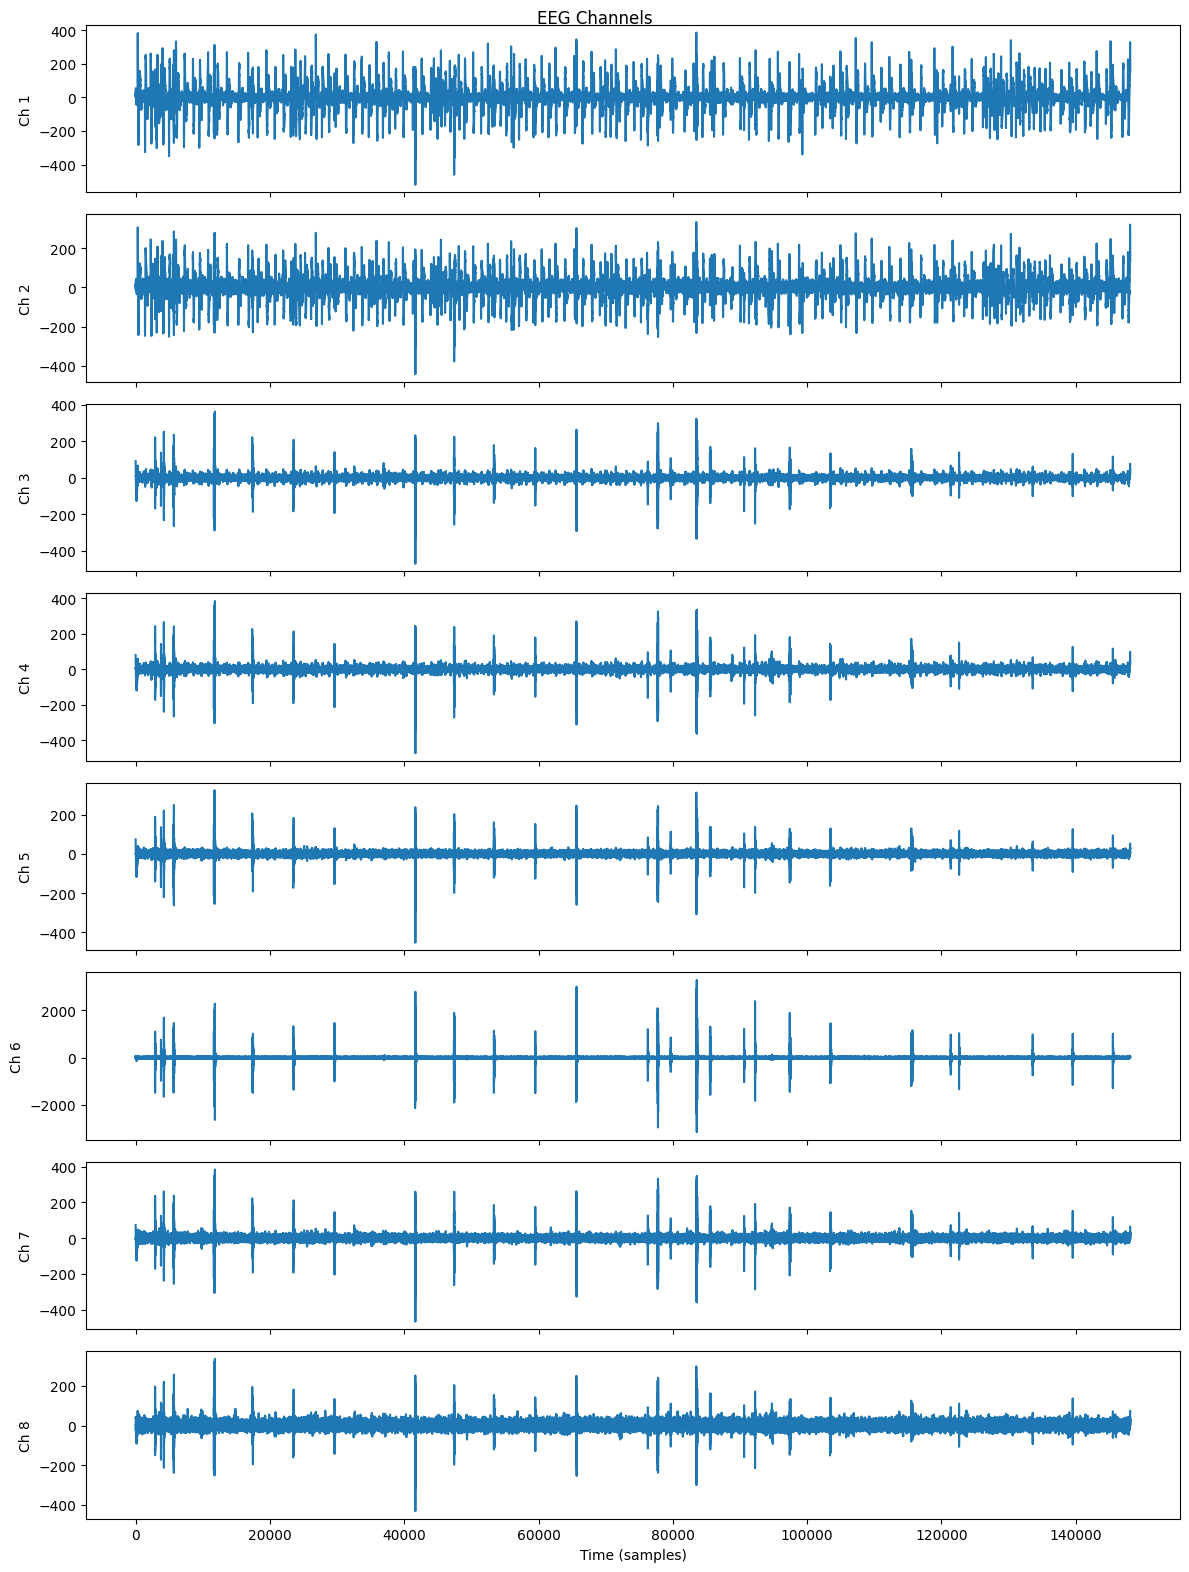

In [15]:
import matplotlib.pyplot as plt
import numpy as np

n_ch, n_samples = eeg_data.shape
t = np.arange(n_samples)

fig, axes = plt.subplots(n_ch, 1, figsize=(12, 2*n_ch), sharex=True)

for ch in range(n_ch):
    axes[ch].plot(t, eeg_data[ch])
    axes[ch].set_ylabel(f"Ch {ch+1}")

axes[-1].set_xlabel("Time (samples)")
fig.suptitle("EEG Channels")
plt.tight_layout()
plt.show()